<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/3_02_Library_Prep_and_QC_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2 — Library Preparation Strategies & Raw/Alignment QC

**Advanced Bioinformatics Lab Session**

## Learning objectives
- Distinguish DNA-Seq, RNA-Seq, ChIP-Seq, and ATAC-Seq library prep and their downstream applications
- Simulate FASTQ data and compute the core FastQC-style raw-data QC metrics from first principles (per-base quality, GC content, duplication, adapter contamination)
- Compute alignment-level QC metrics (mapping rate, coverage depth, insert size distribution) analogous to SAMtools/Picard output
- Diagnose and fix common library-prep artifacts (GC bias, over-amplification, adapter read-through)

This notebook builds every metric manually with NumPy/Pandas so you see exactly what tools like **FastQC**, **MultiQC**, **SAMtools**, and **Picard** are computing under the hood.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

np.random.seed(7)
sns.set_theme(style="whitegrid", font_scale=1.05)
BASES = ["A","C","G","T"]
ADAPTER = "AGATCGGAAGAGC"  # Illumina TruSeq adapter, standard trimming target


## 1. Library types at a glance

| Library | Key steps | Application |
|---|---|---|
| DNA-Seq | Fragmentation → end repair → adapter ligation → PCR | WGS, variant discovery |
| RNA-Seq | RNA isolation → rRNA depletion/poly-A selection → cDNA synthesis → library construction | Expression profiling, DE analysis |
| ChIP-Seq | Crosslinking → immunoprecipitation → DNA purification → sequencing | TF binding, histone marks |
| ATAC-Seq | Tn5 transposase inserts adapters into open chromatin | Chromatin accessibility, regulatory elements |

We'll simulate a **DNA-Seq** FASTQ run and deliberately inject the artifacts described in the troubleshooting table (GC bias, duplication, adapter contamination), then detect them computationally — the same task you'd do on a real `fastq.gz`.

## 2. Simulate a FASTQ dataset with injectable artifacts

In [ ]:
def random_seq(length, gc=0.5):
    w = [(1-gc)/2, gc/2, gc/2, (1-gc)/2]
    return "".join(np.random.choice(BASES, size=length, p=w))

def simulate_quality_string(length, mean_start=38, decay=0.12):
    # Illumina-style quality decay toward the 3' end (Phred, sanger offset 33)
    scores = []
    for pos in range(length):
        q = max(2, np.random.normal(mean_start - decay*pos, 2.5))
        scores.append(int(np.clip(q, 2, 41)))
    return "".join(chr(q+33) for q in scores)

def simulate_fastq(n_reads=2000, read_len=100, gc=0.5, dup_fraction=0.0,
                    adapter_contam_fraction=0.0, unique_pool_size=None):
    if unique_pool_size is None:
        unique_pool_size = int(n_reads * (1 - dup_fraction) * 0.98) + 1
    pool = [random_seq(read_len, gc=gc) for _ in range(unique_pool_size)]

    records = []
    for i in range(n_reads):
        if np.random.rand() < dup_fraction and len(records) > 0:
            seq = np.random.choice(pool)  # simulate PCR duplicate (exact re-pick)
        else:
            seq = np.random.choice(pool)
        seq = list(seq)
        if np.random.rand() < adapter_contam_fraction:
            cut = np.random.randint(read_len - len(ADAPTER) - 5, read_len - len(ADAPTER))
            seq[cut:cut+len(ADAPTER)] = list(ADAPTER)
        seq = "".join(seq)
        qual = simulate_quality_string(read_len)
        records.append({"id": f"read_{i}", "seq": seq, "qual": qual})
    return pd.DataFrame(records)

# A "problem" run: GC-biased, over-amplified, adapter read-through
fastq_df = simulate_fastq(n_reads=2000, read_len=100, gc=0.68,
                           dup_fraction=0.35, adapter_contam_fraction=0.15)
fastq_df.head()


,id,seq,qual
0,read_0,CGGACTACTATTTGAACCGTCTAGGTGTTCGGCCGTACCGGTCACC...,GHFHIFDJFHHBACG@FCFCEGDFFE>A@BDDEDCBDCBAD@CBAC...
1,read_1,GGGGACCACCCCGCGCCCAAGTGGCTGAGGAGGCAGTACCTCTACG...,GDFGJDFFFIGFHDEHIDDDBABBEHBAA=BEDFACCGCB>D@AAA...
2,read_2,CTGGTGGGAGTTGGCGATTATCCGTCCAAAACGCCCTTCCTATAAT...,EIGFEDEECEEDEFFICFECEDCCEAFFCEGCBDDBAAFEBECA@C...
3,read_3,ACGGTCGTGCGCGCCGCTCGGGCGGGCCCGAAGGCTCCGACGGGGG...,GEBEHEIFEDAFA@>CDFCIDCB?@GCBEDACCDADD@ABCEFA@@...
4,read_4,CGCACCCCGCCACCAGCCCGTGTCGGCGCCGCCCGCTCGCATGCCC...,HEIIFCFGFIFDDJAHDFFGEBDHCBI?CA@CDD@FDECCFBDC@=...


## 3. Raw-data QC — reimplementing FastQC's core metrics

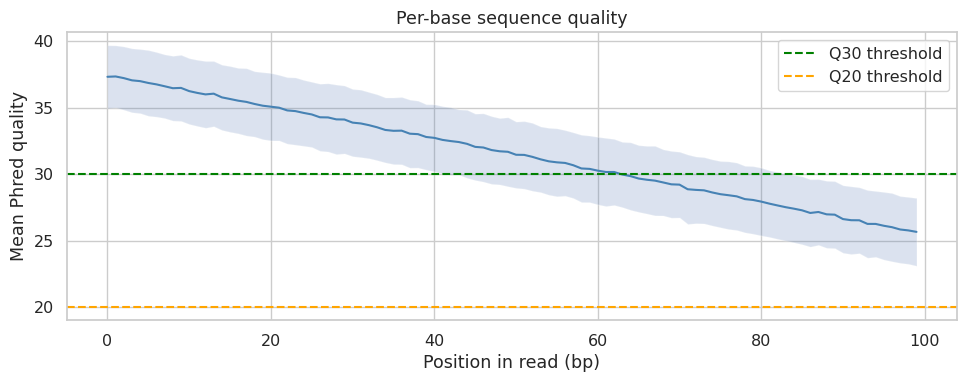

In [ ]:
def phred_scores(qual_str):
    return np.array([ord(c) - 33 for c in qual_str])

# --- Per-base sequence quality ---
qual_matrix = np.array([phred_scores(q) for q in fastq_df["qual"]])
per_base_mean_q = qual_matrix.mean(axis=0)

plt.figure(figsize=(10,4))
plt.plot(per_base_mean_q, color="steelblue")
plt.fill_between(range(len(per_base_mean_q)),
                  per_base_mean_q - qual_matrix.std(axis=0),
                  per_base_mean_q + qual_matrix.std(axis=0), alpha=0.2)
plt.axhline(30, color="green", linestyle="--", label="Q30 threshold")
plt.axhline(20, color="orange", linestyle="--", label="Q20 threshold")
plt.xlabel("Position in read (bp)"); plt.ylabel("Mean Phred quality")
plt.title("Per-base sequence quality"); plt.legend(); plt.tight_layout(); plt.show()


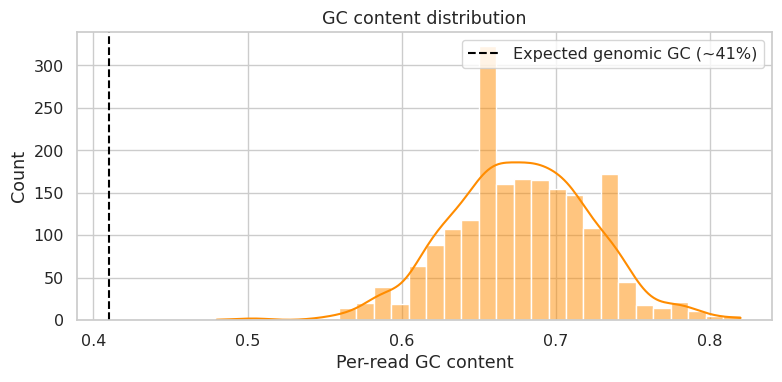

Mean GC content observed: 67.7%  (expected ~41% for a typical human-like genome)


In [ ]:
# --- GC content distribution ---
def gc_content(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

fastq_df["gc"] = fastq_df["seq"].apply(gc_content)

plt.figure(figsize=(8,4))
sns.histplot(fastq_df["gc"], bins=30, kde=True, color="darkorange")
plt.axvline(0.41, color="black", linestyle="--", label="Expected genomic GC (~41%)")
plt.xlabel("Per-read GC content"); plt.title("GC content distribution")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Mean GC content observed: {fastq_df['gc'].mean():.1%}  (expected ~41% for a typical human-like genome)")


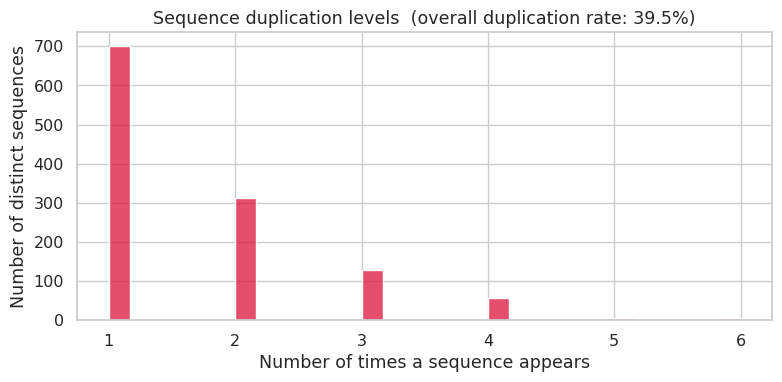

In [ ]:
# --- Sequence duplication levels ---
dup_counts = fastq_df["seq"].value_counts()
dup_rate = 1 - (dup_counts.index.size / len(fastq_df))

plt.figure(figsize=(8,4))
sns.histplot(dup_counts.values, bins=30, color="crimson")
plt.xlabel("Number of times a sequence appears"); plt.ylabel("Number of distinct sequences")
plt.title(f"Sequence duplication levels  (overall duplication rate: {dup_rate:.1%})")
plt.tight_layout(); plt.show()


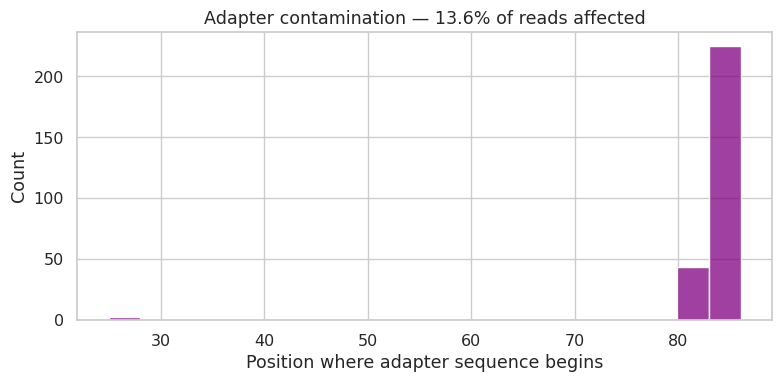

Adapter contamination rate: 13.6%  (FastQC flags >5-10% as a warning/failure)


In [ ]:
# --- Adapter contamination scan ---
def adapter_hit(seq, adapter=ADAPTER, min_match=8):
    for start in range(len(seq) - min_match + 1):
        if seq[start:start+min_match] == adapter[:min_match]:
            return start
    return -1

fastq_df["adapter_pos"] = fastq_df["seq"].apply(adapter_hit)
contam_rate = (fastq_df["adapter_pos"] != -1).mean()

plt.figure(figsize=(8,4))
hit_positions = fastq_df.loc[fastq_df["adapter_pos"] != -1, "adapter_pos"]
sns.histplot(hit_positions, bins=20, color="purple")
plt.xlabel("Position where adapter sequence begins")
plt.title(f"Adapter contamination — {contam_rate:.1%} of reads affected")
plt.tight_layout(); plt.show()

print(f"Adapter contamination rate: {contam_rate:.1%}  (FastQC flags >5-10% as a warning/failure)")


## 4. QC summary dashboard (MultiQC-style aggregate table)

In [ ]:
qc_summary = pd.DataFrame({
    "metric": ["Mean Q30 fraction", "Mean GC content", "Duplication rate", "Adapter contamination rate"],
    "value": [
        (qual_matrix >= 30).mean(),
        fastq_df["gc"].mean(),
        dup_rate,
        contam_rate
    ],
    "flag": [
        "PASS" if (qual_matrix >= 30).mean() > 0.8 else "WARN",
        "WARN (GC bias, PCR artifact)" if abs(fastq_df['gc'].mean() - 0.41) > 0.05 else "PASS",
        "FAIL (over-amplification)" if dup_rate > 0.2 else "PASS",
        "FAIL (poor adapter trimming)" if contam_rate > 0.1 else "PASS",
    ]
})
qc_summary["value"] = qc_summary["value"].map(lambda x: f"{x:.1%}")
qc_summary


,metric,value,flag
0,Mean Q30 fraction,66.7%,WARN
1,Mean GC content,67.7%,"WARN (GC bias, PCR artifact)"
2,Duplication rate,39.5%,FAIL (over-amplification)
3,Adapter contamination rate,13.6%,FAIL (poor adapter trimming)


## 5. Troubleshooting table (from lecture) — map your findings to root cause and fix

| Issue | Root cause | Fix |
|---|---|---|
| Low reads | Poor library preparation | Optimize prep |
| GC bias | PCR bias | PCR-free library prep |
| High duplication | Over-amplification | Reduce PCR cycles |
| Adapter contamination | Poor trimming | Use Cutadapt |
| Low mapping rate | Contamination | Clean reads |

### Exercise 5.1 — Fix the run
Using the `qc_summary` table above, identify **which two issues** this simulated run exhibits, and implement the corresponding fix in code below:
1. Write a `trim_adapters()` function that removes adapter sequence and everything 3′ of it (mimicking Cutadapt).
2. Re-run the adapter contamination scan on the trimmed reads and confirm the rate drops toward 0%.

In [ ]:
def trim_adapters(seq, adapter=ADAPTER, min_match=8):
    pos = adapter_hit(seq, adapter, min_match)
    return seq[:pos] if pos != -1 else seq

fastq_df["seq_trimmed"] = fastq_df["seq"].apply(trim_adapters)
fastq_df["adapter_pos_after"] = fastq_df["seq_trimmed"].apply(adapter_hit)
contam_rate_after = (fastq_df["adapter_pos_after"] != -1).mean()
print(f"Adapter contamination BEFORE trimming: {contam_rate:.1%}")
print(f"Adapter contamination AFTER  trimming: {contam_rate_after:.1%}")


Adapter contamination BEFORE trimming: 13.6%
Adapter contamination AFTER  trimming: 0.0%


## 6. Alignment QC (SAMtools / Picard analogues)

After trimming and aligning reads to a reference, three metrics matter most: **mapping rate**, **coverage depth**, and **insert size distribution** (for paired-end data). We simulate an alignment outcome consistent with the QC issues you just diagnosed.

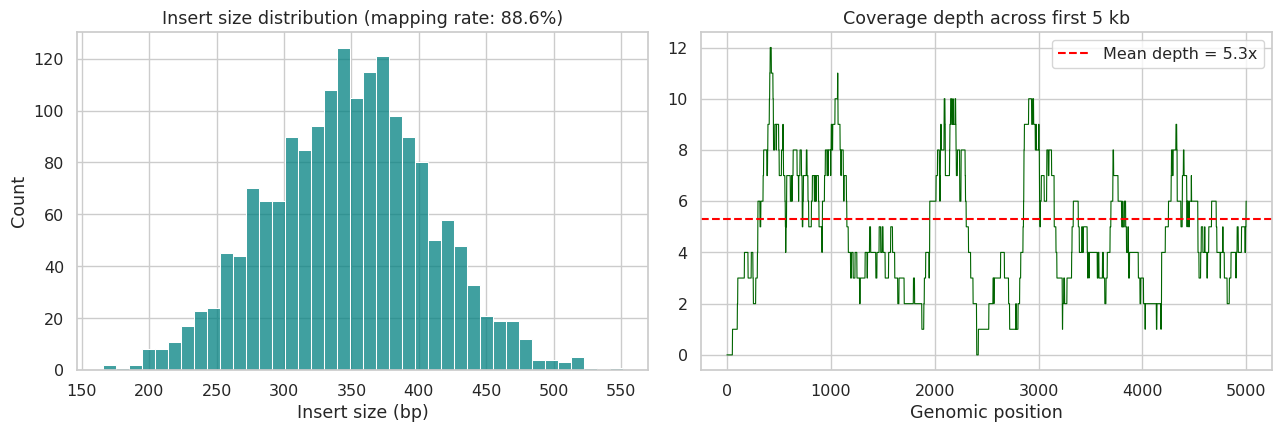

Mapping rate: 88.6%  (Picard/SAMtools flag <90% as investigate-worthy)


In [ ]:
def simulate_alignment(n_reads, genome_len=50000, contamination_fraction=0.0):
    mapped = np.random.rand(n_reads) > contamination_fraction
    positions = np.random.randint(0, genome_len, size=mapped.sum())
    insert_sizes = np.random.normal(350, 60, size=mapped.sum()).clip(50, 900)
    return mapped, positions, insert_sizes

n_reads = len(fastq_df)
mapped, positions, insert_sizes = simulate_alignment(n_reads, contamination_fraction=0.12)
mapping_rate = mapped.mean()

coverage = np.zeros(50000)
for p in positions:
    coverage[p:p+150] += 1

fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.histplot(insert_sizes, bins=40, ax=axes[0], color="teal")
axes[0].set_title(f"Insert size distribution (mapping rate: {mapping_rate:.1%})")
axes[0].set_xlabel("Insert size (bp)")

axes[1].plot(coverage[:5000], color="darkgreen", lw=0.8)
axes[1].axhline(coverage.mean(), color="red", linestyle="--", label=f"Mean depth = {coverage.mean():.1f}x")
axes[1].set_title("Coverage depth across first 5 kb")
axes[1].set_xlabel("Genomic position"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Mapping rate: {mapping_rate:.1%}  (Picard/SAMtools flag <90% as investigate-worthy)")


## 7. Final diagnostic report

Complete the report below using the metrics you computed in this notebook.

| QC metric | Observed value | PASS/WARN/FAIL | Likely root cause | Recommended fix |
|---|---|---|---|---|
| Q30 fraction | | | | |
| GC content | | | | |
| Duplication rate | | | | |
| Adapter contamination (pre-trim) | | | | |
| Mapping rate | | | | |

### Discussion questions
1. Why does PCR-free library prep reduce GC bias specifically (link back to the polymerase amplification step)?
2. If duplication rate is high but the library is **not** over-amplified, what's the other likely explanation (hint: think about low-input DNA-Seq)?
3. Why is insert size distribution only meaningful for paired-end sequencing, and what does a bimodal insert size distribution usually indicate?
